In [1]:
!pip install easyocr
!pip install imutils

In [2]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import imutils
import easyocr

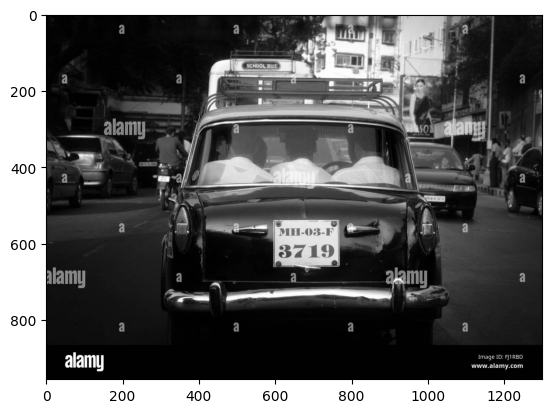

In [3]:
img = cv2.imread("taxi-cab-in-mumbai-india-FJ1RBD.jpg") # replace with your image filename 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

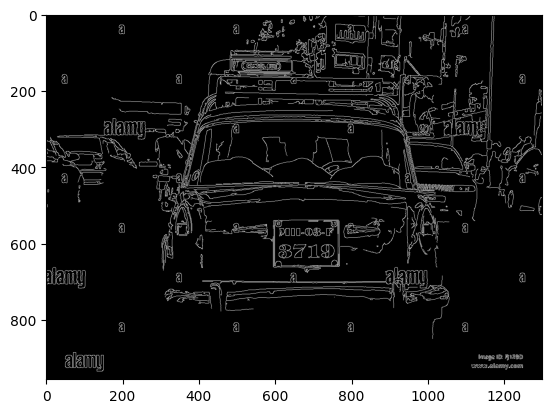

In [4]:
gray = cv2.bilateralFilter(gray, 11, 17, 17) # smooth while keeping edges 
edged = cv2.Canny(gray, 30, 200) #edge detection
plt.imshow(cv2.cvtColor(edged, cv2.COLOR_BGR2RGB))

In [5]:
contours, _ = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) 
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:30]

In [6]:
location = None
for contour in contours: 
    epsilon = 0.018 * cv2.arcLength(contour, True) 
    approx = cv2.approxPolyDP(contour, epsilon, True) 
    
    if len(approx) == 4:
        x, y, w, h = cv2.boundingRect(contour) 
        aspect_ratio = w / float(h) 
        
        if cv2.contourArea(contour) > 2000 and 2 < aspect_ratio < 6: 
            location = approx 
            break

In [11]:
import cv2
import numpy as np
import easyocr

# Example: define plate_roi by cropping from the image
# Replace these coordinates with your detection output
x, y, w, h = 100, 200, 120, 40   # sample bounding box
plate_roi = img[y:y+h, x:x+w]

if plate_roi is not None and plate_roi.size > 0:
    # Convert to grayscale
    plate_roi_gray = cv2.cvtColor(plate_roi, cv2.COLOR_BGR2GRAY)

    # Adaptive thresholding
    plate_roi_thresh = cv2.adaptiveThreshold(
        plate_roi_gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    # Invert if background is dark
    if np.mean(plate_roi_thresh) > 127:
        plate_roi_thresh = cv2.bitwise_not(plate_roi_thresh)

    # OCR with EasyOCR
    reader = easyocr.Reader(['en'])
    result = reader.readtext(plate_roi_thresh)

    if len(result) > 0:
        # EasyOCR format: [ [bbox, text, confidence], ... ]
        plate_text = result[0][1]   # index 1 is the text string
        print("Detected Plate:", plate_text)
    else:
        print("No text detected in ROI")
else:
    print("Plate ROI is empty or not detected")

No text detected in ROI


In [12]:
plate_text = "" 
if plate_roi is not None: 
    reader = easyocr.Reader(['en']) 
    result = reader.readtext(plate_roi) 
    
    if len(result) > 0: 
        plate_text = result[0][-2] 
        print("Detected Plate:", plate_text)

In [13]:
if location is not None: 
    cv2.polylines(img, [location.astype(int)], True, (0,255,0), 3) 
    
    # Center text inside plate 
    x, y, w, h = cv2.boundingRect(location) 
    font = cv2.FONT_HERSHEY_SIMPLEX
    text_size = cv2.getTextSize(plate_text, font, 1, 2)[0] 
    text_x = x + (w - text_size[0]) // 2 
    text_y = y + (h + text_size[1]) // 2 
    cv2.putText(img, plate_text, (text_x, text_y), 
                font, 1, (0,255,0), 2, cv2.LINE_AA)


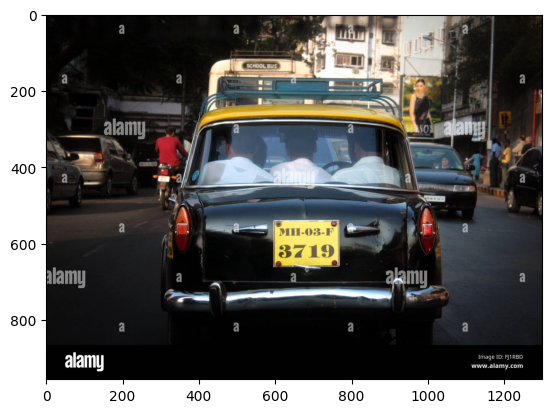

In [14]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) 
plt.show()

In [15]:
if plate_roi is not None:
    reader = easyocr.Reader(['en'])
    result = reader.readtext(plate_roi)

    if len(result) > 0:
        plate_text = result[0][-2]
        print("Detected Plate Number:", plate_text)   # <-- separate print


In [18]:
import cv2
import numpy as np
import easyocr

# Load the image
img = cv2.imread("taxi1.jpg")   # replace with your file path

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Noise reduction
gray = cv2.bilateralFilter(gray, 11, 17, 17)

# Edge detection
edges = cv2.Canny(gray, 30, 200)

# Find contours
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

plate_roi = None
for c in contours:
    # Approximate contour
    approx = cv2.approxPolyDP(c, 0.018*cv2.arcLength(c, True), True)
    if len(approx) == 4:  # likely a rectangle
        x, y, w, h = cv2.boundingRect(c)
        plate_roi = img[y:y+h, x:x+w]
        break

if plate_roi is not None and plate_roi.size > 0:
    # Preprocess ROI
    plate_gray = cv2.cvtColor(plate_roi, cv2.COLOR_BGR2GRAY)
    plate_thresh = cv2.adaptiveThreshold(
        plate_gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    # OCR
    reader = easyocr.Reader(['en'])
    result = reader.readtext(plate_thresh)

    if len(result) > 0:
        plate_text = result[0][1]   # text is at index 1
        print("Detected Plate:", img)
    else:
        print("No text detected in ROI")
else:
    print("No plate ROI found")

No plate ROI found


In [19]:
cv2.imwrite("detected_plate_output.png", img)

True

In [20]:
import cv2
import numpy as np
import easyocr

# Load the image (update path to your uploaded file)
img = cv2.imread("taxi1.jpg")

if img is None:
    raise FileNotFoundError("Image not found. Check the file path!")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.bilateralFilter(gray, 11, 17, 17)
edges = cv2.Canny(gray, 30, 200)

# Find contours
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

plate_roi = None
plate_coords = None
for c in contours:
    approx = cv2.approxPolyDP(c, 0.018*cv2.arcLength(c, True), True)
    if len(approx) == 4:  # likely a rectangle
        x, y, w, h = cv2.boundingRect(c)
        plate_roi = img[y:y+h, x:x+w]
        plate_coords = (x, y, w, h)
        break

if plate_roi is not None and plate_roi.size > 0:
    plate_gray = cv2.cvtColor(plate_roi, cv2.COLOR_BGR2GRAY)
    plate_thresh = cv2.adaptiveThreshold(
        plate_gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    reader = easyocr.Reader(['en'])
    result = reader.readtext(plate_thresh)

    if len(result) > 0:
        plate_text = result[0][1]
        print("Detected Plate:", plate_text)

        # Show the cropped plate ROI
        cv2.imshow("Plate ROI", plate_roi)

        # Draw rectangle around plate on original image
        x, y, w, h = plate_coords
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # Overlay detected text above the plate
        cv2.putText(img, plate_text, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # Show the annotated car image
        cv2.imshow("Detected Plate on Car", img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    else:
        print("No text detected in ROI")
else:
    print("No plate ROI found")

No plate ROI found


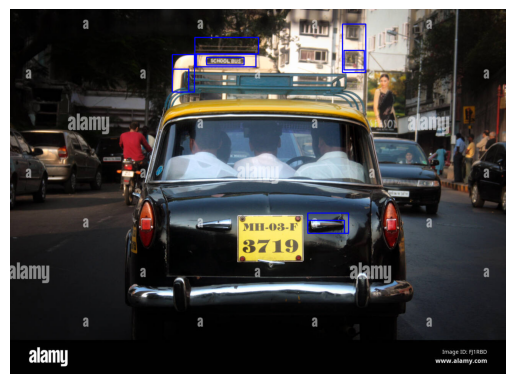

In [22]:
import matplotlib.pyplot as plt

# Convert BGR (OpenCV default) to RGB (Matplotlib expects RGB)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [24]:
if plate_roi is not None and plate_roi.size > 0:
    plt.imshow(cv2.cvtColor(plate_roi, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
else:
    print("Plate ROI is empty — detection failed")

Plate ROI is empty — detection failed


Detected: 4 (confidence: 0.40)
Detected: a (confidence: 0.95)
Detected: School dus (confidence: 0.17)
Detected: a (confidence: 0.98)
Detected: a (confidence: 0.92)
Detected: alamy (confidence: 1.00)
Detected: SoL (confidence: 0.05)
Detected: alamy (confidence: 1.00)
Detected: A (confidence: 0.18)
Detected: 4 (confidence: 0.25)
Detected: MII-O3-F (confidence: 0.42)
Detected: 3719 (confidence: 0.88)
Detected: a (confidence: 0.99)
Detected: aamy (confidence: 1.00)
Detected: a (confidence: 0.89)
Detected: a (confidence: 0.94)
Detected: a (confidence: 0.96)
Detected: Image ID: FJIRBD (confidence: 0.99)
Detected: alamy (confidence: 1.00)
Detected: WWW alamy com (confidence: 0.72)
Detected: alamy (confidence: 0.99)


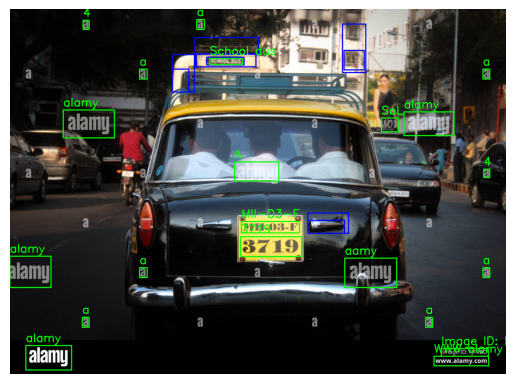

In [25]:
import easyocr
import matplotlib.pyplot as plt

reader = easyocr.Reader(['en'])
result = reader.readtext(img)

for (bbox, text, confidence) in result:
    print(f"Detected: {text} (confidence: {confidence:.2f})")
    # Draw bounding box and text
    (top_left, top_right, bottom_right, bottom_left) = bbox
    top_left = tuple(map(int, top_left))
    bottom_right = tuple(map(int, bottom_right))
    cv2.rectangle(img, top_left, bottom_right, (0,255,0), 2)
    cv2.putText(img, text, (top_left[0], top_left[1]-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

# Show annotated image in Jupyter
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Detected Plate: MII-O3-F


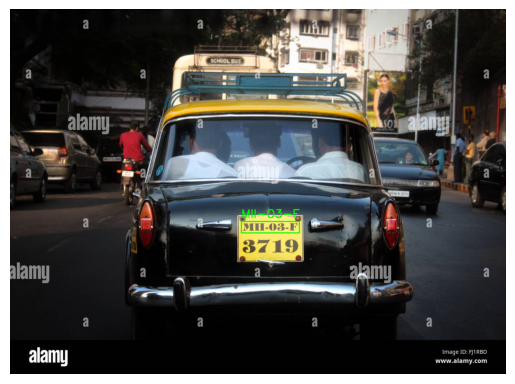

In [26]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("taxi1.jpg")
if img is None:
    raise FileNotFoundError("Image not found. Check the path!")

# Run EasyOCR on the full image
reader = easyocr.Reader(['en'])
results = reader.readtext(img)

plate_text = None
for (bbox, text, confidence) in results:
    # Filter: keep only text that looks like a plate (digits + letters, length reasonable)
    if any(char.isdigit() for char in text) and len(text) >= 5:
        plate_text = text
        # Draw bounding box
        (top_left, top_right, bottom_right, bottom_left) = bbox
        top_left = tuple(map(int, top_left))
        bottom_right = tuple(map(int, bottom_right))
        cv2.rectangle(img, top_left, bottom_right, (0,255,0), 2)
        cv2.putText(img, text, (top_left[0], top_left[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

print("Detected Plate:", plate_text if plate_text else "No plate detected")

# Show annotated image in Jupyter
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Detected Plate: HR.26 BR.9044


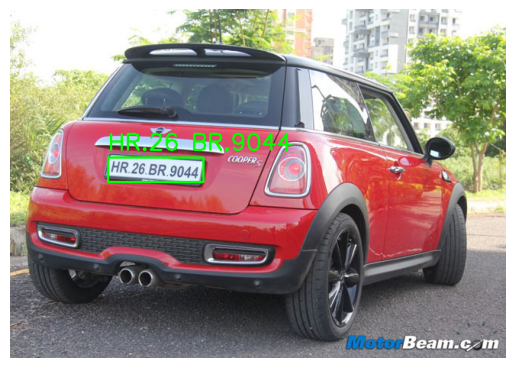

In [28]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("image1.jpg")
if img is None:
    raise FileNotFoundError("Image not found. Check the path!")

reader = easyocr.Reader(['en'])
results = reader.readtext(img)

plate_texts = []
for (bbox, text, confidence) in results:
    # Filter: keep only text that looks like plate (letters + digits)
    if any(char.isdigit() for char in text) and len(text) >= 3:
        plate_texts.append(text)
        # Draw bounding box
        (top_left, top_right, bottom_right, bottom_left) = bbox
        top_left = tuple(map(int, top_left))
        bottom_right = tuple(map(int, bottom_right))
        cv2.rectangle(img, top_left, bottom_right, (0,255,0), 2)
        cv2.putText(img, text, (top_left[0], top_left[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

# Combine detected parts into one string
plate_full = " ".join(plate_texts)
print("Detected Plate:", plate_full if plate_full else "No plate detected")

# Show annotated image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Detected Plate: MII-O3-F 3719


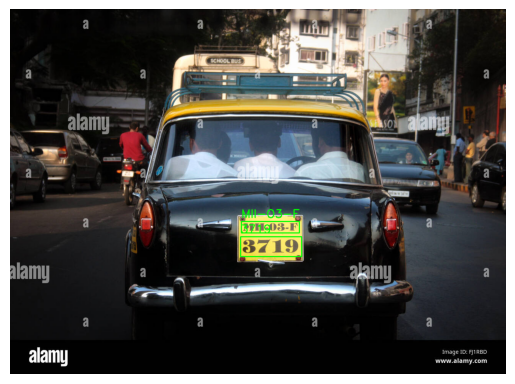

In [27]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("taxi1.jpg")
if img is None:
    raise FileNotFoundError("Image not found. Check the path!")

reader = easyocr.Reader(['en'])
results = reader.readtext(img)

plate_texts = []
for (bbox, text, confidence) in results:
    # Filter: keep only text that looks like plate (letters + digits)
    if any(char.isdigit() for char in text) and len(text) >= 3:
        plate_texts.append(text)
        # Draw bounding box
        (top_left, top_right, bottom_right, bottom_left) = bbox
        top_left = tuple(map(int, top_left))
        bottom_right = tuple(map(int, bottom_right))
        cv2.rectangle(img, top_left, bottom_right, (0,255,0), 2)
        cv2.putText(img, text, (top_left[0], top_left[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

# Combine detected parts into one string
plate_full = " ".join(plate_texts)
print("Detected Plate:", plate_full if plate_full else "No plate detected")

# Show annotated image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Detected Plate: Ri77 TC 0510


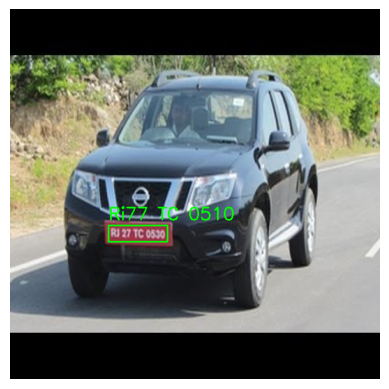

In [29]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("oo.jpg")
if img is None:
    raise FileNotFoundError("Image not found. Check the path!")

reader = easyocr.Reader(['en'])
results = reader.readtext(img)

plate_texts = []
for (bbox, text, confidence) in results:
    # Filter: keep only text that looks like plate (letters + digits)
    if any(char.isdigit() for char in text) and len(text) >= 3:
        plate_texts.append(text)
        # Draw bounding box
        (top_left, top_right, bottom_right, bottom_left) = bbox
        top_left = tuple(map(int, top_left))
        bottom_right = tuple(map(int, bottom_right))
        cv2.rectangle(img, top_left, bottom_right, (0,255,0), 2)
        cv2.putText(img, text, (top_left[0], top_left[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

# Combine detected parts into one string
plate_full = " ".join(plate_texts)
print("Detected Plate:", plate_full if plate_full else "No plate detected")

# Show annotated image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Detected Plate: DL 6 Ck6683


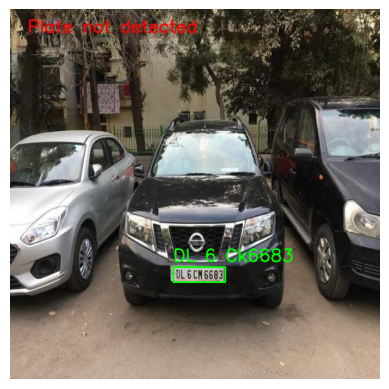

In [30]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("output.jpg")
if img is None:
    raise FileNotFoundError("Image not found. Check the path!")

reader = easyocr.Reader(['en'])
results = reader.readtext(img)

plate_texts = []
for (bbox, text, confidence) in results:
    # Filter: keep only text that looks like plate (letters + digits)
    if any(char.isdigit() for char in text) and len(text) >= 3:
        plate_texts.append(text)
        # Draw bounding box
        (top_left, top_right, bottom_right, bottom_left) = bbox
        top_left = tuple(map(int, top_left))
        bottom_right = tuple(map(int, bottom_right))
        cv2.rectangle(img, top_left, bottom_right, (0,255,0), 2)
        cv2.putText(img, text, (top_left[0], top_left[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

# Combine detected parts into one string
plate_full = " ".join(plate_texts)
print("Detected Plate:", plate_full if plate_full else "No plate detected")

# Show annotated image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Raw OCR Plate: DL 6 Ck6683


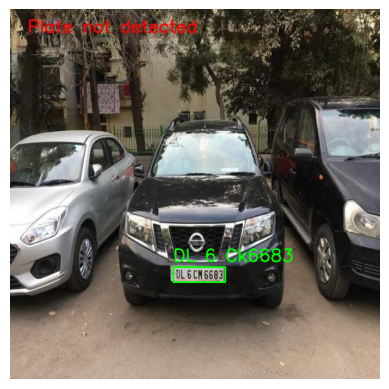

In [32]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import re

# Load the image (update path to your uploaded file)
img = cv2.imread("output.jpg")
if img is None:
    raise FileNotFoundError("Image not found. Check the path!")

# Run EasyOCR on the full image
reader = easyocr.Reader(['en'])
results = reader.readtext(img)

plate_texts = []
for (bbox, text, confidence) in results:
    # Keep only text that looks like a plate (letters + digits)
    if any(char.isdigit() for char in text) and len(text) >= 3:
        plate_texts.append(text)
        # Draw bounding box
        (top_left, top_right, bottom_right, bottom_left) = bbox
        top_left = tuple(map(int, top_left))
        bottom_right = tuple(map(int, bottom_right))
        cv2.rectangle(img, top_left, bottom_right, (0,255,0), 2)
        cv2.putText(img, text, (top_left[0], top_left[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

# Combine detected parts into one string
plate_full = " ".join(plate_texts)
print("Raw OCR Plate:", plate_full if plate_full else "No plate detected")

# Regex correction for Indian plate format (e.g., DL 6 CM 6683)
pattern = r"[A-Z]{2}\s?\d{1,2}\s?[A-Z]{1,2}\d{4}"
match = re.search(pattern, plate_full.replace(" ", ""))
if match:
    corrected_plate = match.group()
    print("Corrected Plate:", corrected_plate)
else:
    corrected_plate = plate_full

# Show annotated image inline
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Raw OCR Plate: DL 6 Ck6683


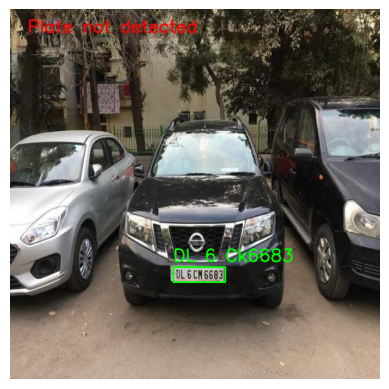

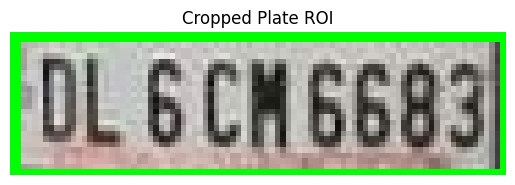

In [33]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import re

# Load the image (update path to your uploaded file)
img = cv2.imread("output.jpg")
if img is None:
    raise FileNotFoundError("Image not found. Check the path!")

reader = easyocr.Reader(['en'])
results = reader.readtext(img)

plate_texts = []
plate_boxes = []
for (bbox, text, confidence) in results:
    # Keep only text that looks like a plate (letters + digits)
    if any(char.isdigit() for char in text) and len(text) >= 3:
        plate_texts.append(text)
        plate_boxes.append(bbox)
        # Draw bounding box on full image
        (top_left, top_right, bottom_right, bottom_left) = bbox
        top_left = tuple(map(int, top_left))
        bottom_right = tuple(map(int, bottom_right))
        cv2.rectangle(img, top_left, bottom_right, (0,255,0), 2)
        cv2.putText(img, text, (top_left[0], top_left[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

# Combine detected parts into one string
plate_full = " ".join(plate_texts)
print("Raw OCR Plate:", plate_full if plate_full else "No plate detected")

# Regex correction for Indian plate format
pattern = r"[A-Z]{2}\s?\d{1,2}\s?[A-Z]{1,2}\d{4}"
match = re.search(pattern, plate_full.replace(" ", ""))
if match:
    corrected_plate = match.group()
    print("Corrected Plate:", corrected_plate)
else:
    corrected_plate = plate_full

# Show annotated car image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# --- Crop and show only the plate ROI ---
if plate_boxes:
    # Take the first detected plate box
    (top_left, top_right, bottom_right, bottom_left) = plate_boxes[0]
    x_min = int(min(top_left[0], bottom_left[0]))
    y_min = int(min(top_left[1], top_right[1]))
    x_max = int(max(top_right[0], bottom_right[0]))
    y_max = int(max(bottom_left[1], bottom_right[1]))

    plate_roi = img[y_min:y_max, x_min:x_max]

    plt.imshow(cv2.cvtColor(plate_roi, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Cropped Plate ROI")
    plt.show()
else:
    print("No plate ROI found to crop")